# Deck EDA — Training Data Coverage

## Goal
分析具体 deck 的 replay 数、命名 top deck 的训练数据覆盖，以及同 archetype 的相近牌组。数据量本身不能证明模型性能瓶颈。

## Context & Methods
- raw_replays：原始 deck CSV 中唯一 (date, episode) 数；镜像对局计一次。
- train_replays / train_action_samples：复用训练 holdout/full_data 筛选后的训练池对局数 / 动作数，包含配置启用的败方增强。
- expert_*：沿用 expert_validation_ratio；至少一方达到当日参与者分数门槛的**专家对局**，不保证行动方自身为专家。
- changed_slots：相对 top deck 更换的卡位数（考虑重复卡），0 为完全相同。
- 统计训练池，不是单 epoch 曝光量；max_samples、shuffle、重复 epoch 不改变训练池计数。
- 原始日期可能多于 cache，见 context。不同 deck 的 replay 数不能直接相加作为 archetype 唯一对局数。

In [1]:
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root():
    for parent in (Path.cwd(), *Path.cwd().parents):
        for candidate in (parent, parent / 'imitation_learning'):
            if (candidate / 'analysis' / 'deck_coverage.py').is_file():
                return candidate
    raise FileNotFoundError('Open this notebook from inside the repository')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from analysis.deck_coverage import run_coverage, plot_coverage
TRAIN_CONFIG = PROJECT_ROOT / 'cfg' / 'train_policy.yaml'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'deck_eda'


## Data
直接复用 train YAML 的 top decks、cache、专家和隔离配置，无需重复配置。读取全部 CSV 和 cache 元数据可能耗时数分钟，不启动模型训练。

In [2]:
summary, variants, census, context = run_coverage(PROJECT_ROOT, TRAIN_CONFIG)
display(context)


Loading deck CSVs...
Counting 17,940,945 selected training actions...


{'train_config': 'D:\\learning\\AI\\Kaggle\\The Pokémon Company - PTCG AI Battle Challenge Simulation\\imitation_learning\\cfg\\train_policy.yaml',
 'data_selection_mode': 'holdout',
 'raw_dates': [(6, 27),
  (6, 28),
  (6, 29),
  (6, 30),
  (7, 1),
  (7, 2),
  (7, 3),
  (7, 4),
  (7, 5),
  (7, 6),
  (7, 7),
  (7, 8),
  (7, 9),
  (7, 10),
  (7, 11),
  (7, 12),
  (7, 13),
  (7, 14),
  (7, 15),
  (7, 16),
  (7, 17),
  (7, 18),
  (7, 19),
  (7, 20),
  (7, 21),
  (7, 22),
  (7, 23),
  (7, 24),
  (7, 25),
  (7, 26),
  (7, 27),
  (7, 28),
  (7, 29),
  (7, 30),
  (7, 31),
  (8, 1),
  (8, 2),
  (8, 3),
  (8, 4),
  (8, 5),
  (8, 6),
  (8, 7),
  (8, 8),
  (8, 9),
  (8, 10),
  (8, 11),
  (8, 12),
  (8, 13),
  (8, 14),
  (8, 15)],
 'cache_dates': [(6, 27),
  (6, 28),
  (6, 29),
  (6, 30),
  (7, 1),
  (7, 2),
  (7, 3),
  (7, 4),
  (7, 5),
  (7, 6),
  (7, 7),
  (7, 8),
  (7, 9),
  (7, 10),
  (7, 11),
  (7, 12),
  (7, 13),
  (7, 14),
  (7, 15),
  (7, 16),
  (7, 17),
  (7, 18),
  (7, 19),
  (7, 20),
 

## Results
### 1. 所有具体 deck 的数据量
保留最有用的完整 deck 计数，显示前 100 行。

In [3]:
display(census.drop(columns=['card_ids']).head(100))


,raw_replays,expert_raw_replays,train_replays,expert_train_replays,train_action_samples,expert_train_action_samples,deck_id,archetype
439,63433,5821,34571,3640,3554141,378108,D-C20A8A46F5C6,Marnie Grimmsnarl
504,42031,4611,20955,2478,1632391,197432,D-3F4515092DC5,Alakazam
384,27191,2847,13426,1475,1332349,148501,D-E2E03FE8EF95,Marnie Grimmsnarl
447,15447,1442,7654,691,616908,57394,D-C04E65DE725B,Cynthia Garchomp
432,15391,1663,7229,895,537420,63015,D-F1776EE333FE,Alakazam
...,...,...,...,...,...,...,...,...
541,626,50,323,16,25216,1282,D-94F9B92041C4,Team Rocket Mewtwo
647,622,10,285,4,25730,381,D-AB14898F4E99,Marnie Grimmsnarl
443,618,23,286,8,18726,660,D-43B3939C7860,Archaludon
956,601,15,281,2,19868,151,D-15AC57BA89FA,Alakazam


### 2. 命名 top deck 的精确牌组覆盖
没有数据的配置牌组也显示为 0；专家动作样本数不等于独立对局数。

In [4]:
display(summary.drop(columns=['card_ids']))


,name,deck_id,archetype,raw_replays,expert_raw_replays,train_replays,expert_train_replays,train_action_samples,expert_train_action_samples
0,grimmsnarl,D-C20A8A46F5C6,Marnie Grimmsnarl,63433,5821,34571,3640,3554141,378108
1,alakazam,D-3F4515092DC5,Alakazam,42031,4611,20955,2478,1632391,197432
2,mega_froslass,D-DD63244CB42C,Mega Froslass,11612,1380,5875,840,472671,66168
3,mega_lucario,D-77A53FFC32F8,Mega Lucario,4026,1505,2489,1161,165006,73994
4,dragapult,D-07BEDFFFBFAD,Dragapult,8400,1023,4011,674,469508,77394
5,mega_kangaskhan,D-DF6F74437196,Mega Kangaskhan,1958,317,980,187,66413,12206
6,festival_lead,D-7E3984370203,Festival Lead,1570,331,671,226,47001,16277


### 3. 同 archetype 的相近牌组
只计算相对指定 top deck 的相似度，不生成全量两两相似度表。完整 CSV 包含 card_ids。

In [5]:
for name in summary.name:
    print(f'deck({name})')
    display(variants[variants.name == name].drop(columns=['card_ids']).head(30))


deck(grimmsnarl)


,name,deck_id,archetype,changed_slots,weighted_jaccard,raw_replays,expert_raw_replays,train_replays,expert_train_replays,train_action_samples,expert_train_action_samples
8,grimmsnarl,D-C20A8A46F5C6,Marnie Grimmsnarl,0,1.000000,63433,5821,34571,3640,3554141,378108
22,grimmsnarl,D-22A88F292DF4,Marnie Grimmsnarl,1,0.967213,3989,89,1777,33,160849,3011
59,grimmsnarl,D-A9CF3D228C6A,Marnie Grimmsnarl,1,0.967213,521,12,238,3,28232,421
83,grimmsnarl,D-F1E80A062976,Marnie Grimmsnarl,1,0.967213,288,7,132,3,13290,287
60,grimmsnarl,D-DE5B9940C5BE,Marnie Grimmsnarl,1,0.967213,176,0,61,0,6269,0
85,grimmsnarl,D-9D41ABE5BE83,Marnie Grimmsnarl,1,0.967213,40,1,19,0,1911,0
62,grimmsnarl,D-414250334BD4,Marnie Grimmsnarl,1,0.967213,31,0,14,0,1421,0
113,grimmsnarl,D-3AF9C0ED2EDA,Marnie Grimmsnarl,1,0.967213,27,0,7,0,795,0
88,grimmsnarl,D-8E068F5EB27B,Marnie Grimmsnarl,1,0.967213,8,0,3,0,315,0
57,grimmsnarl,D-CED625B96351,Marnie Grimmsnarl,1,0.967213,4,0,1,0,159,0


deck(alakazam)


,name,deck_id,archetype,changed_slots,weighted_jaccard,raw_replays,expert_raw_replays,train_replays,expert_train_replays,train_action_samples,expert_train_action_samples
265,alakazam,D-3F4515092DC5,Alakazam,0,1.000000,42031,4611,20955,2478,1632391,197432
242,alakazam,D-F1776EE333FE,Alakazam,1,0.967213,15391,1663,7229,895,537420,63015
283,alakazam,D-6FF20626E51A,Alakazam,1,0.967213,1236,33,561,9,41221,700
374,alakazam,D-8359B175FE82,Alakazam,1,0.967213,45,0,23,0,1740,0
431,alakazam,D-A2B90315CA0B,Alakazam,1,0.967213,33,4,15,4,1118,287
290,alakazam,D-CC1A49D0CF89,Alakazam,1,0.967213,7,0,4,0,285,0
315,alakazam,D-F7E1ADFE46D5,Alakazam,1,0.967213,7,0,2,0,128,0
428,alakazam,D-46E08B7B9E87,Alakazam,1,0.967213,7,0,5,0,346,0
415,alakazam,D-E964DEACE8F5,Alakazam,1,0.967213,3,0,1,0,93,0
432,alakazam,D-B6FCC1C7D4CB,Alakazam,1,0.967213,3,0,2,0,144,0


deck(mega_froslass)


...

,name,deck_id,archetype,changed_slots,weighted_jaccard,raw_replays,expert_raw_replays,train_replays,expert_train_replays,train_action_samples,expert_train_action_samples
626,dragapult,D-07BEDFFFBFAD,Dragapult,0,1.000000,8400,1023,4011,674,469508,77394
630,dragapult,D-F2F66FC21B19,Dragapult,1,0.967213,1571,51,737,18,83729,2066
625,dragapult,D-544443EECE3C,Dragapult,1,0.967213,724,20,338,7,38882,812
698,dragapult,D-F0314F941A87,Dragapult,1,0.967213,463,21,235,4,25203,398
696,dragapult,D-893DA79E79F0,Dragapult,1,0.967213,231,92,68,49,7505,5504
672,dragapult,D-2B8493C8EE69,Dragapult,1,0.967213,65,5,28,2,3417,235
704,dragapult,D-FE95C21B67C3,Dragapult,1,0.967213,37,0,0,0,0,0
686,dragapult,D-EE2A65C02680,Dragapult,1,0.967213,11,0,0,0,0,0
642,dragapult,D-5A43AD295ED2,Dragapult,2,0.935484,650,129,372,98,42939,11452
649,dragapult,D-A41346A07CC9,Dragapult,2,0.935484,86,12,52,8,6255,921


deck(mega_kangaskhan)


,name,deck_id,archetype,changed_slots,weighted_jaccard,raw_replays,expert_raw_replays,train_replays,expert_train_replays,train_action_samples,expert_train_action_samples
738,mega_kangaskhan,D-DF6F74437196,Mega Kangaskhan,0,1.000000,1958,317,980,187,66413,12206
744,mega_kangaskhan,D-DBD496ADEDD3,Mega Kangaskhan,1,0.967213,86,1,47,0,2897,0
759,mega_kangaskhan,D-E3E65D06012E,Mega Kangaskhan,1,0.967213,48,0,1,0,82,0
742,mega_kangaskhan,D-B02F8DBAA98C,Mega Kangaskhan,1,0.967213,20,0,14,0,763,0
730,mega_kangaskhan,D-29F7227853EB,Mega Kangaskhan,1,0.967213,17,0,9,0,485,0
753,mega_kangaskhan,D-7A7DC4386BB1,Mega Kangaskhan,1,0.967213,2,0,1,0,63,0
752,mega_kangaskhan,D-FE4AF5E55B69,Mega Kangaskhan,2,0.935484,99,2,49,0,3060,0
745,mega_kangaskhan,D-E7FE6A44809C,Mega Kangaskhan,2,0.935484,82,6,47,0,2930,0
761,mega_kangaskhan,D-1C7214267280,Mega Kangaskhan,2,0.935484,37,1,0,0,0,0
746,mega_kangaskhan,D-44F976B162E1,Mega Kangaskhan,3,0.904762,275,75,100,18,6610,1248


deck(festival_lead)


,name,deck_id,archetype,changed_slots,weighted_jaccard,raw_replays,expert_raw_replays,train_replays,expert_train_replays,train_action_samples,expert_train_action_samples
809,festival_lead,D-7E3984370203,Festival Lead,0,1.000000,1570,331,671,226,47001,16277
811,festival_lead,D-5C8EBE71D4AE,Festival Lead,1,0.967213,169,5,52,0,4111,0
828,festival_lead,D-148E09407B23,Festival Lead,1,0.967213,90,18,42,12,2804,778
834,festival_lead,D-091CA96B0ABE,Festival Lead,2,0.935484,66,1,0,0,0,0
782,festival_lead,D-68C95EACC12A,Festival Lead,3,0.904762,575,17,284,7,20010,577
838,festival_lead,D-8998E638265B,Festival Lead,3,0.904762,1,0,0,0,0,0
790,festival_lead,D-A0C76728E82F,Festival Lead,4,0.875000,702,40,313,25,21532,1609
823,festival_lead,D-815267FF473F,Festival Lead,4,0.875000,254,70,138,48,9728,3640
850,festival_lead,D-503C9F0A7272,Festival Lead,4,0.875000,50,0,22,0,1569,0
839,festival_lead,D-0488EAA5E4C3,Festival Lead,5,0.846154,8,0,0,0,0,0


### 4. 图表与输出
同名文件每次覆盖。散点图每个点代表一个具体 deck，纵轴为可显示 0 的对称对数刻度。

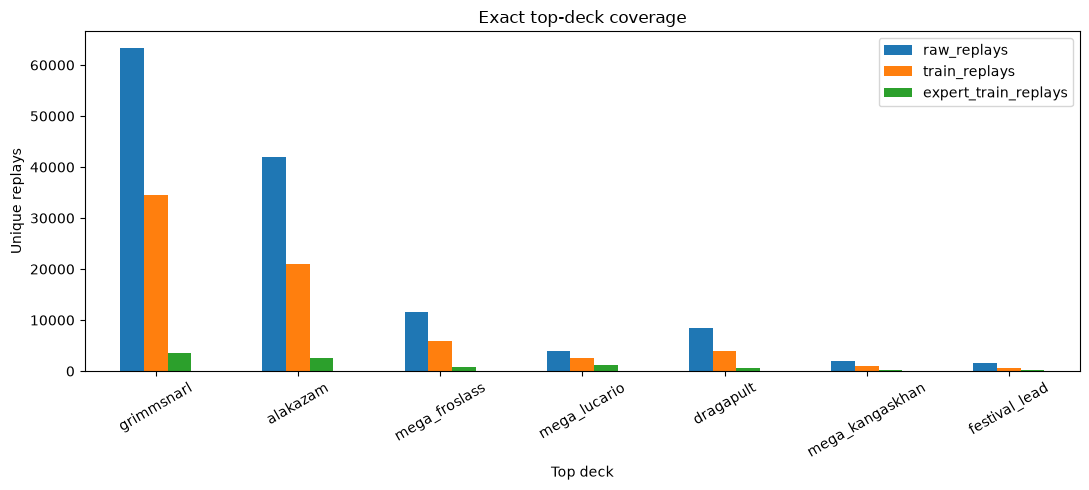

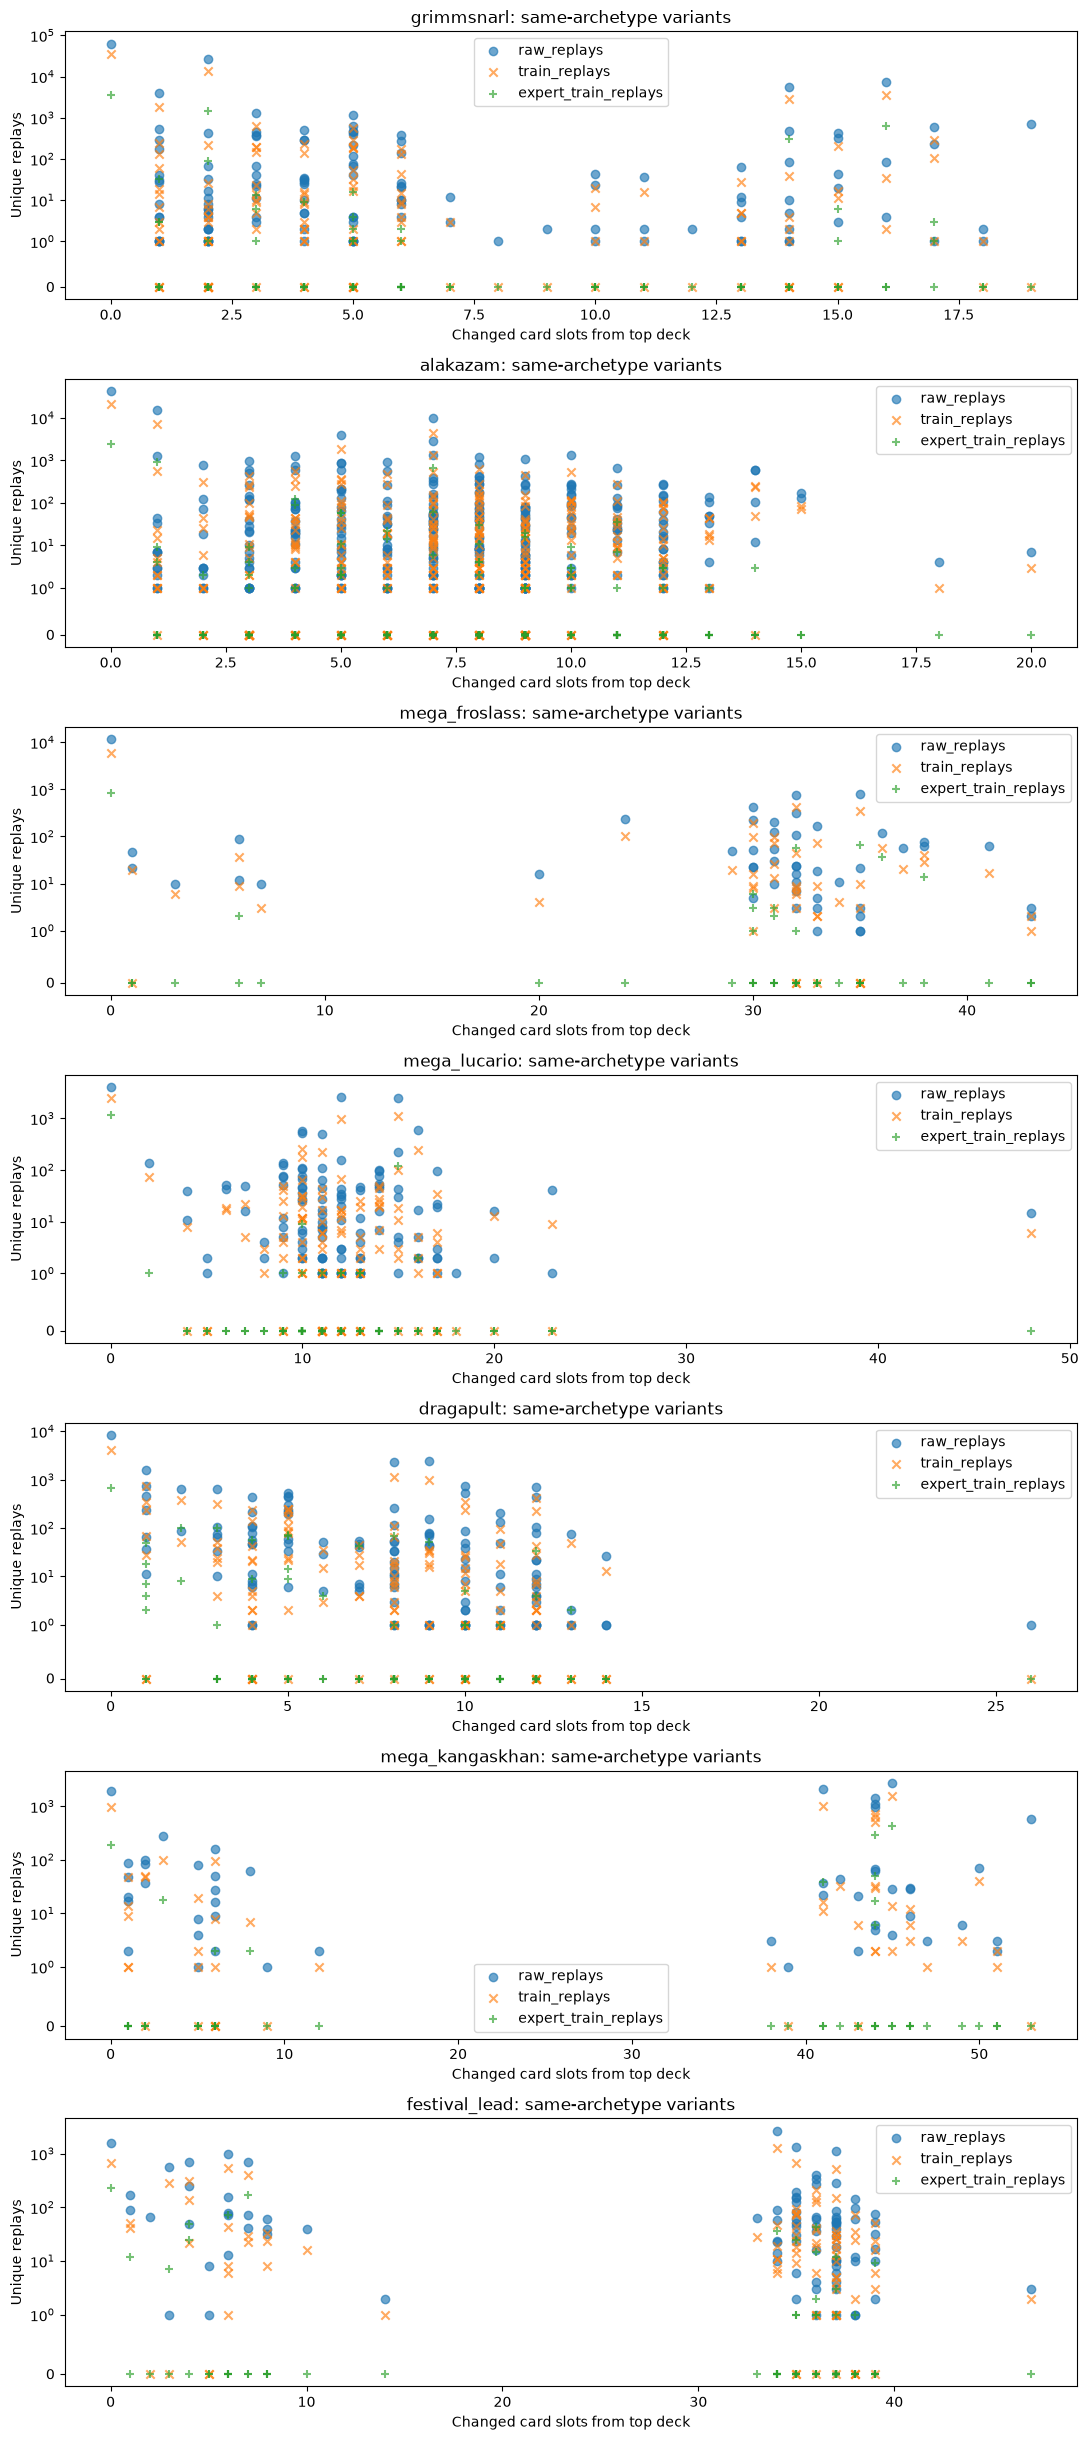

Saved to d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\outputs\deck_eda


In [6]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
census.to_csv(OUTPUT_DIR / 'deck_coverage.csv', index=False)
summary.to_csv(OUTPUT_DIR / 'top_deck_coverage.csv', index=False)
variants.to_csv(OUTPUT_DIR / 'top_deck_archetype_variants.csv', index=False)
(OUTPUT_DIR / 'coverage_context.json').write_text(json.dumps(context, ensure_ascii=False, indent=2), encoding='utf-8')
figures = plot_coverage(summary, variants, OUTPUT_DIR)
plt.show()
for figure in figures:
    plt.close(figure)
print(f'Saved to {OUTPUT_DIR}')


## Checks
计数层级和训练池动作总数一致性检查，不代表模型性能验证。

In [8]:
for table in (summary, variants, census):
    assert (table.expert_raw_replays <= table.raw_replays).all()
    assert (table.expert_train_replays <= table.train_replays).all()
    assert (table.train_replays <= table.raw_replays).all()
    assert (table.train_replays <= table.train_action_samples).all()
    assert (table.expert_train_action_samples <= table.train_action_samples).all()
assert int(census.train_action_samples.sum()) == context['train_action_samples']
print('Coverage checks passed')


Coverage checks passed


## Takeaways
- 精确 deck 数据少但相近变体多：可能有可迁移数据。
- 同 archetype 相近变体、专家对局和训练动作都少：值得进一步检查数据覆盖。
- 原始多但训练少：检查日期、holdout、隔离、胜负筛选和采样比例。
- 是否真正受数据量限制仍需结合独立验证表现或固定验证集的数据规模实验，本 notebook 不预先下结论。